<a href="https://colab.research.google.com/github/Luckysolex/Data-Science-Methodologies/blob/master/capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset and Project Overview**

# **Walmart Recruiting - Store Sales Forecasting**
The dataset contains historical sales data for 45 Walmart stores located in different regions. Each store contains a number of departments, and the goal is to predict the department-wide sales for each store.

In addition, Walmart runs several promotional markdown events throughout the year. These markdowns precede prominent holidays, the four largest of which are the Super Bowl, Labor Day, Thanksgiving, and Christmas. The weeks including these holidays are weighted five times higher in the evaluation than non-holiday weeks. Part of the challenge presented by this competition is modeling the effects of markdowns on these holiday weeks in the absence of complete/ideal historical data.
### **Data Files**
**stores.csv**

This file contains anonymized information about the 45 stores, indicating the type and size of store.

**train.csv**

This is the historical training data, which covers to 2010-02-05 to 2012-11-01. Within this file you will find the following fields:

`Store` - the store number <br>
`Dept` - the department number <br>
`Date` - the week <br>
`Weekly_Sales` -  sales for the given department in the given store <br>
`IsHoliday` - whether the week is a special holiday week <br>

**test.csv**

This file is identical to train.csv, except we have withheld the weekly sales. You must predict the sales for each triplet of store, department, and date in this file.

**features.csv**

This file contains additional data related to the store, department, and regional activity for the given dates. It contains the following fields:

`Store` - the store number <br>
`Date` - the week <br>
`Temperature` - average temperature in the region <br>
`Fuel_Price` - cost of fuel in the region <br>
`MarkDown1-5` - anonymized data related to promotional markdowns that Walmart is running. MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA. <br>
`CPI` - the consumer price index <br>
`Unemployment` - the unemployment rate <br>
`IsHoliday` - whether the week is a special holiday week <br>

For convenience, the four holidays fall within the following weeks in the dataset (not all holidays are in the data):
- Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
- Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
- Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
- Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

The task is to predict Weekly Sales for specific departments across 45 different Walmart stores. A key challenge is that Walmart holds major promotional events (Markdowns) before four major holidays: Super Bowl, Labor Day, Thanksgiving, and Christmas. These weeks have a significantly higher impact on total revenue and are weighted more heavily in the evaluation.

### Libraries and Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
features = pd.read_csv('/content/sample_data/features.csv')
stores = pd.read_csv('/content/sample_data/stores.csv')
test = pd.read_csv('/content/sample_data/test.csv')
train = pd.read_csv('/content/sample_data/train.csv')

### Data Check

In [4]:
print('First 5 rows of Features Dataset:')
display(features.head())
print('\nFirst 5 rows of Stores Dataset:')
display(stores.head())
print('\nFirst 5 rows of Test Dataset:')
display(test.head())
print('\nFirst 5 rows of Train Dataset:')
display(train.head())

First 5 rows of Features Dataset:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



First 5 rows of Stores Dataset:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



First 5 rows of Test Dataset:


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False



First 5 rows of Train Dataset:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
print('Shape Features Dataset:')
display(features.shape)
print('Shape Stores Dataset:')
display(stores.shape)
print('Shape Test Dataset:')
display(test.shape)
print('Shape Train Dataset:')
display(train.shape)

Shape Features Dataset:


(8190, 12)

Shape Stores Dataset:


(45, 3)

Shape Test Dataset:


(115064, 4)

Shape Train Dataset:


(421570, 5)

In [6]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


####
---
## Stage 1 *(The Master Merge)*
---
####

In [7]:
# Identification of Train VS Test dataset
train['is_train'] = 1
test['is_train'] = 0

df = pd.concat([train, test], axis=0).reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
dtypes: bool(1), float64(1), int64(3), object(1)
memory usage: 21.0+ MB


In [8]:
df = pd.merge(df, stores, on='Store', how='left')

print(df.shape)
display(df.head())

(536634, 8)


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size
0,1,1,2010-02-05,24924.50,False,1,A,151315
1,1,1,2010-02-12,46039.49,True,1,A,151315
2,1,1,2010-02-19,41595.55,False,1,A,151315
3,1,1,2010-02-26,19403.54,False,1,A,151315
4,1,1,2010-03-05,21827.90,False,1,A,151315


In [9]:
df = pd.merge(df, features, on=['Store', 'Date', 'IsHoliday'], how='left')

print(df.shape)
display(df.head())

(536634, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


####
---
### Stage 2 *(Handling Missing Values)*
---
####

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
 6   Type          536634 non-null  object 
 7   Size          536634 non-null  int64  
 8   Temperature   536634 non-null  float64
 9   Fuel_Price    536634 non-null  float64
 10  MarkDown1     265596 non-null  float64
 11  MarkDown2     197685 non-null  float64
 12  MarkDown3     242326 non-null  float64
 13  MarkDown4     237143 non-null  float64
 14  MarkDown5     266496 non-null  float64
 15  CPI           498472 non-null  float64
 16  Unemployment  498472 non-null  float64
dtypes: bool(1), float64(10), int64(4), object(2)
mem

**Missing values appears in all Markdown 1-5, let's fill them up with 0**

In [11]:
df.fillna(0, inplace=True)

In [12]:
# Confirm there's no other missing values

df.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
is_train,0
Type,0
Size,0
Temperature,0
Fuel_Price,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         536634 non-null  int64  
 1   Dept          536634 non-null  int64  
 2   Date          536634 non-null  object 
 3   Weekly_Sales  536634 non-null  float64
 4   IsHoliday     536634 non-null  bool   
 5   is_train      536634 non-null  int64  
 6   Type          536634 non-null  object 
 7   Size          536634 non-null  int64  
 8   Temperature   536634 non-null  float64
 9   Fuel_Price    536634 non-null  float64
 10  MarkDown1     536634 non-null  float64
 11  MarkDown2     536634 non-null  float64
 12  MarkDown3     536634 non-null  float64
 13  MarkDown4     536634 non-null  float64
 14  MarkDown5     536634 non-null  float64
 15  CPI           536634 non-null  float64
 16  Unemployment  536634 non-null  float64
dtypes: bool(1), float64(10), int64(4), object(2)
mem

In [14]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


####
---
### Stage 3 *(Feature Engineering)*
---
####

In [15]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         536634 non-null  int64         
 1   Dept          536634 non-null  int64         
 2   Date          536634 non-null  datetime64[ns]
 3   Weekly_Sales  536634 non-null  float64       
 4   IsHoliday     536634 non-null  bool          
 5   is_train      536634 non-null  int64         
 6   Type          536634 non-null  object        
 7   Size          536634 non-null  int64         
 8   Temperature   536634 non-null  float64       
 9   Fuel_Price    536634 non-null  float64       
 10  MarkDown1     536634 non-null  float64       
 11  MarkDown2     536634 non-null  float64       
 12  MarkDown3     536634 non-null  float64       
 13  MarkDown4     536634 non-null  float64       
 14  MarkDown5     536634 non-null  float64       
 15  CPI           536

**Temporal Features** <br> Extraction of `Month`, `Day`, `WeekOfYear`, and `Year` from the Date

In [16]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [17]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear
0,1,1,2010-02-05,24924.50,False,1,A,151315,42.31,2.572,...,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010,5
1,1,1,2010-02-12,46039.49,True,1,A,151315,38.51,2.548,...,0.0,0.0,0.0,0.0,211.242170,8.106,12,2,2010,6
2,1,1,2010-02-19,41595.55,False,1,A,151315,39.93,2.514,...,0.0,0.0,0.0,0.0,211.289143,8.106,19,2,2010,7
3,1,1,2010-02-26,19403.54,False,1,A,151315,46.63,2.561,...,0.0,0.0,0.0,0.0,211.319643,8.106,26,2,2010,8
4,1,1,2010-03-05,21827.90,False,1,A,151315,46.50,2.625,...,0.0,0.0,0.0,0.0,211.350143,8.106,5,3,2010,9


**The "Days to Holiday" Feature** <br>
Since Black Friday and Christmas move, create a counter for *"Days until next major Holiday."*

Here, I used the 4 christmas dates mentioned above in the introduction and used them as major holidays. That's what I understood by the script given

In [18]:
major_holiday = ['31-Dec-10', '30-Dec-11', '28-Dec-12', '27-Dec-13']
major_holiday = pd.to_datetime(major_holiday)

In [19]:
major_holiday

DatetimeIndex(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'], dtype='datetime64[ns]', freq=None)

In [20]:
holiday = pd.DataFrame({'next_holiday' :major_holiday})

df = df.sort_values('Date')
holiday

,next_holiday
0,2010-12-31
1,2011-12-30
2,2012-12-28
3,2013-12-27


In [21]:
df.dropna(subset=['Date'], inplace=True)
df = pd.merge_asof(df, holiday, left_on='Date', right_on='next_holiday', direction='forward')

df.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday
63175,29,4,2010-07-02,15477.28,False,1,B,93638,72.88,2.815,...,0.00,0.00,0.00,132.521867,10.409,2,7,2010,26,2010-12-31
325996,35,44,2012-03-16,1665.52,False,1,B,103681,49.60,3.862,...,1.20,1587.92,2214.43,141.554780,8.744,16,3,2012,11,2012-12-28
531548,32,37,2013-07-19,0.00,False,0,A,203007,72.29,3.585,...,110.06,742.88,1040.07,0.000000,0.000,19,7,2013,29,2013-12-27
524501,32,34,2013-06-28,0.00,False,0,A,203007,75.37,3.691,...,36.70,3524.09,2824.23,0.000000,0.000,28,6,2013,26,2013-12-27
350499,9,44,2012-05-11,4227.02,False,1,B,125833,70.94,3.688,...,1.04,356.78,1077.81,225.478263,5.539,11,5,2012,19,2012-12-28
474216,35,3,2013-03-01,0.00,False,0,B,103681,39.90,3.890,...,4.98,54.65,2250.11,142.960046,8.600,1,3,2013,9,2013-12-27
168766,33,18,2011-03-11,55.95,False,1,A,39690,66.51,3.630,...,0.00,0.00,0.00,128.399500,8.951,11,3,2011,10,2011-12-30
55580,36,9,2010-06-11,101.68,False,1,A,39910,82.30,2.615,...,0.00,0.00,0.00,210.213567,8.464,11,6,2010,23,2010-12-31
386712,4,60,2012-08-10,432.00,False,1,A,205863,83.21,3.476,...,60.94,4777.20,3937.09,130.756161,4.077,10,8,2012,32,2012-12-28
288102,39,74,2011-12-23,31460.13,False,1,A,184109,54.62,3.112,...,1339.10,213.49,4911.65,218.054185,7.716,23,12,2011,51,2011-12-30


In [22]:
df['next_holiday'].unique()

<DatetimeArray>
['2010-12-31 00:00:00', '2011-12-30 00:00:00', '2012-12-28 00:00:00',
 '2013-12-27 00:00:00']
Length: 4, dtype: datetime64[ns]

In [23]:
df['Days_To_Holiday'] = (df['next_holiday'] - df['Date']).dt.days

df.sample(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday
533785,19,50,2013-07-26,0.00,False,0,A,203819,68.96,3.951,...,84.91,1993.50,0.000000,0.000,26,7,2013,30,2013-12-27,154
56933,30,97,2010-06-18,13886.27,False,1,C,42988,86.18,2.637,...,0.00,0.00,211.109654,8.200,18,6,2010,24,2010-12-31,196
296649,7,5,2012-01-06,20010.01,False,1,B,70713,18.67,3.095,...,162.72,4504.47,196.545831,8.256,6,1,2012,1,2012-12-28,357
168444,32,40,2011-03-11,61404.58,False,1,A,203007,36.51,3.372,...,0.00,0.00,192.058484,8.818,11,3,2011,10,2011-12-30,294
225727,19,50,2011-07-22,537.00,False,1,A,203819,79.37,3.972,...,0.00,0.00,135.873839,7.806,22,7,2011,29,2011-12-30,161
192877,19,19,2011-05-06,-2.44,False,1,A,203819,50.43,4.192,...,0.00,0.00,134.514367,7.658,6,5,2011,18,2011-12-30,238
115522,14,92,2010-11-05,206935.29,False,1,A,200898,45.65,2.917,...,0.00,0.00,182.946365,8.724,5,11,2010,44,2010-12-31,56
347856,37,17,2012-05-11,350.54,False,1,C,39910,76.55,3.688,...,0.00,1500.11,220.407558,6.989,11,5,2012,19,2012-12-28,231
101660,30,10,2010-10-01,124.74,False,1,C,42988,70.28,2.603,...,0.00,0.00,211.329874,8.163,1,10,2010,39,2010-12-31,91
138996,45,19,2010-12-31,1100.27,True,1,B,118221,29.67,3.179,...,0.00,0.00,182.571448,8.724,31,12,2010,52,2010-12-31,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            536634 non-null  int64         
 1   Dept             536634 non-null  int64         
 2   Date             536634 non-null  datetime64[ns]
 3   Weekly_Sales     536634 non-null  float64       
 4   IsHoliday        536634 non-null  bool          
 5   is_train         536634 non-null  int64         
 6   Type             536634 non-null  object        
 7   Size             536634 non-null  int64         
 8   Temperature      536634 non-null  float64       
 9   Fuel_Price       536634 non-null  float64       
 10  MarkDown1        536634 non-null  float64       
 11  MarkDown2        536634 non-null  float64       
 12  MarkDown3        536634 non-null  float64       
 13  MarkDown4        536634 non-null  float64       
 14  MarkDown5        536

**Lag Features** <br> Create a column for `Sales_Last_Year` by shifting sales data by 52 weeks. This is the strongest predictor for seasonal retail

In [25]:
df['Sales_Last_Year'] = df['Weekly_Sales'].shift(52)

df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year
536629,4,25,2013-07-26,0.0,False,0,A,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536630,8,87,2013-07-26,0.0,False,0,A,155078,78.70,3.620,...,2343.11,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536631,25,46,2013-07-26,0.0,False,0,B,128107,68.72,3.804,...,1129.68,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536632,4,26,2013-07-26,0.0,False,0,A,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536633,45,98,2013-07-26,0.0,False,0,B,118221,76.06,3.804,...,1864.57,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0


######
Create an `Avg_Dept_Sales` column to give the model a baseline of how big a specific department usually is.
######

In [26]:
Avg_Dept_Sales = df.groupby('Dept')['Weekly_Sales'].mean()

Avg_Dept_Sales

,Weekly_Sales
Dept,
1,15096.309712
2,34262.658661
3,9266.477405
4,20408.638044
5,16772.709780
...,...
95,54862.046706
96,11901.018079
97,11195.460583


####
---
### Stage 4 *(Categorical Encoding)*
---
####

In [27]:
df['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

In [28]:
# Encoding `Type` column using direct mapping
mapping = {'A': 1, 'B': 2, 'C': 3}

df['Type'] = df['Type'].map(mapping)

In [29]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year
536629,4,25,2013-07-26,0.0,False,0,1,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536630,8,87,2013-07-26,0.0,False,0,1,155078,78.70,3.620,...,2343.11,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536631,25,46,2013-07-26,0.0,False,0,2,128107,68.72,3.804,...,1129.68,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536632,4,26,2013-07-26,0.0,False,0,1,205863,78.96,3.580,...,1433.77,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0
536633,45,98,2013-07-26,0.0,False,0,2,118221,76.06,3.804,...,1864.57,0.0,0.0,26,7,2013,30,2013-12-27,154,0.0


In [30]:
# Converting `IsHoliday` column to Integer from Boolean
df['IsHoliday'] = df['IsHoliday'].astype(int)

display(df.head())
df.info()

,Store,Dept,Date,Weekly_Sales,IsHoliday,is_train,Type,Size,Temperature,Fuel_Price,...,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,next_holiday,Days_To_Holiday,Sales_Last_Year
0,1,1,2010-02-05,24924.50,0,1,1,151315,42.31,2.572,...,0.0,211.096358,8.106,5,2,2010,5,2010-12-31,329,NaN
1,20,97,2010-02-05,28590.12,0,1,1,203742,25.92,2.784,...,0.0,204.247194,8.187,5,2,2010,5,2010-12-31,329,NaN
2,23,21,2010-02-05,9461.72,0,1,2,114533,15.25,2.788,...,0.0,131.527903,5.892,5,2,2010,5,2010-12-31,329,NaN
3,38,85,2010-02-05,80.08,0,1,3,39690,49.47,2.962,...,0.0,126.442065,13.975,5,2,2010,5,2010-12-31,329,NaN
4,6,80,2010-02-05,14222.74,0,1,1,202505,40.43,2.572,...,0.0,212.622352,7.259,5,2,2010,5,2010-12-31,329,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            536634 non-null  int64         
 1   Dept             536634 non-null  int64         
 2   Date             536634 non-null  datetime64[ns]
 3   Weekly_Sales     536634 non-null  float64       
 4   IsHoliday        536634 non-null  int64         
 5   is_train         536634 non-null  int64         
 6   Type             536634 non-null  int64         
 7   Size             536634 non-null  int64         
 8   Temperature      536634 non-null  float64       
 9   Fuel_Price       536634 non-null  float64       
 10  MarkDown1        536634 non-null  float64       
 11  MarkDown2        536634 non-null  float64       
 12  MarkDown3        536634 non-null  float64       
 13  MarkDown4        536634 non-null  float64       
 14  MarkDown5        536

####
---
### Stage 5 *(Output & Documentation)*
---
####

In [31]:
# To reduce memory usage and file size

int_64 = df.select_dtypes(include=['int64', 'int32', 'UInt32'])

for c in int_64:
    df[c] = df[c].astype('uint8')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536634 entries, 0 to 536633
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            536634 non-null  uint8         
 1   Dept             536634 non-null  uint8         
 2   Date             536634 non-null  datetime64[ns]
 3   Weekly_Sales     536634 non-null  float64       
 4   IsHoliday        536634 non-null  uint8         
 5   is_train         536634 non-null  uint8         
 6   Type             536634 non-null  uint8         
 7   Size             536634 non-null  uint8         
 8   Temperature      536634 non-null  float64       
 9   Fuel_Price       536634 non-null  float64       
 10  MarkDown1        536634 non-null  float64       
 11  MarkDown2        536634 non-null  float64       
 12  MarkDown3        536634 non-null  float64       
 13  MarkDown4        536634 non-null  float64       
 14  MarkDown5        536

In [32]:
final_train = df[df['is_train'] == 1].drop(columns=['is_train'])
final_test = df[df['is_train'] == 0].drop(columns=['is_train', 'Weekly_Sales'])

In [33]:
print('Final Train Dataset Shape:', final_train.shape)
print('Final Test Dataset Shape:', final_test.shape)

Final Train Dataset Shape: (421570, 23)
Final Test Dataset Shape: (115064, 22)


In [34]:
final_train.to_csv('train_final.csv', date_format='%Y-%m-%d', index=False)
final_test.to_csv('test_final.csv', date_format='%Y-%m-%d', index=False)

In [35]:
df.to_csv('final_df.csv', date_format='%Y-%m-%d', index=False)

In [36]:
df['Sales_Last_Year'] = df['Sales_Last_Year'].fillna(0)

# Confirm that there are no more missing values in the Sales_Last_Year column
print('Missing values in Sales_Last_Year:', df['Sales_Last_Year'].isna().sum())
display(df[['Sales_Last_Year']].head())

Missing values in Sales_Last_Year: 0


,Sales_Last_Year
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


####
---
### Stage 6 *(Creating Pipeline)*
---
####

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

In [41]:
# Filtering the training data from the merged dataframe
train_df = df[df['is_train'] == 1]

# Defining features (X) and target (y)
# Dropping the target, identification, and non-numeric datetime columns
X = train_df.drop(columns=['Weekly_Sales', 'is_train', 'Date', 'next_holiday'])
y = train_df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)

Features (X) shape: (421570, 20)
Target (y) shape: (421570,)


In [40]:
display(X.head())

,Store,Dept,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Day,Month,Year,WeekOfYear,Days_To_Holiday,Sales_Last_Year
0,1,1,0,1,19,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,218,5,73,0.0
1,20,97,0,1,222,25.92,2.784,0.0,0.0,0.0,0.0,0.0,204.247194,8.187,5,2,218,5,73,0.0
2,23,21,0,2,101,15.25,2.788,0.0,0.0,0.0,0.0,0.0,131.527903,5.892,5,2,218,5,73,0.0
3,38,85,0,3,10,49.47,2.962,0.0,0.0,0.0,0.0,0.0,126.442065,13.975,5,2,218,5,73,0.0
4,6,80,0,1,9,40.43,2.572,0.0,0.0,0.0,0.0,0.0,212.622352,7.259,5,2,218,5,73,0.0


In [45]:
# Creating the Pipeline with Scaling and XGBoost
model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb_model', xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42))
])

# Training the pipeline
model.fit(X_train, y_train)

print('Model Pipeline created and trained successfully.')

Model Pipeline created and trained successfully.


In [46]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb_model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [47]:
y_train_pred = model.predict(X_train)
print(y_train_pred)

[ 4792.4707  2562.1338 12582.989  ...  5796.655   8215.09   35220.203 ]


In [48]:
# Create a dataframe for Actual vs Predicted values on training dataset
train_pred_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
display(train_pred_df.head())

,Actual,Predicted
138466,2160.01,4792.470703
289214,986.29,2562.133789
52351,6538.43,12582.989258
203504,1141.85,359.703796
233606,50.00,2550.354736


In [49]:
y_test_pred = model.predict(X_test)
print(y_test_pred)

[92918.75   15520.038   8388.604  ...  6437.733   2014.8905 -1296.7709]


In [50]:
# Create dataframe of Actual vs Predicted on the test dataset
test_pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
display(test_pred_df.head())

,Actual,Predicted
272342,103857.48,92918.750000
176581,4681.58,15520.038086
354212,5605.79,8388.603516
281444,6430.00,6311.385742
124208,2514.59,4266.459473


In [51]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R-squared Score: {r2:.4f}')

Mean Absolute Error (MAE): 4267.41
R-squared Score: 0.8970


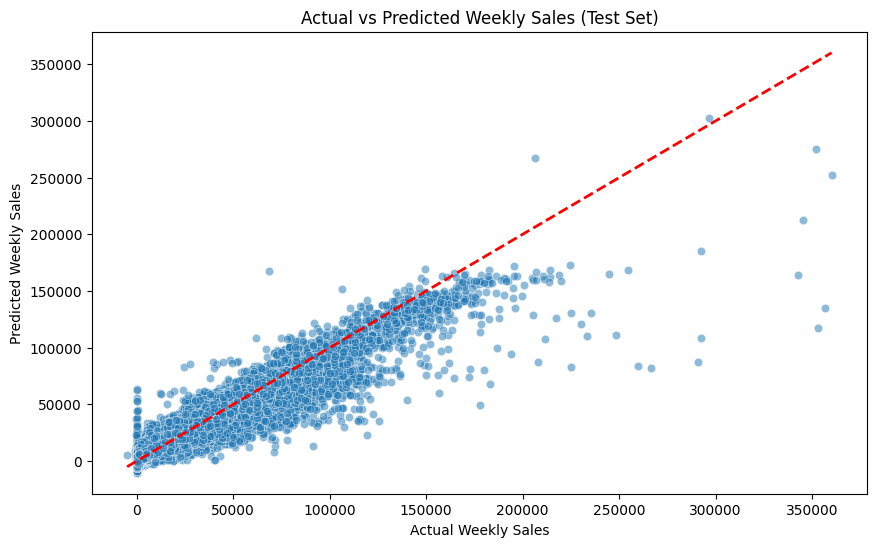

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales (Test Set)')
plt.show()

From the results on the test dataset, we can infer several key points:

1. R-squared Score (0.8970): The model explains approximately 89.7% of the variance in the weekly sales. This is a strong result, suggesting that the features (like store type, size, and the engineered lag features) are highly predictive of sales.
2. Mean Absolute Error (4267.41): On average, the model's predictions are off by about $4,267. Given that Walmart weekly sales can reach hundreds of thousands of dollars for certain departments, this level of error is relatively low, though it may be more significant for smaller departments.
3. Visualization: The scatter plot shows that the points generally cluster closely around the red diagonal line, which represents perfect predictions. However, you'll likely notice some dispersion at higher sales volumes, which is common in retail forecasting as peak holiday spikes are harder to predict perfectly.

Overall, the model is performing quite well and generalizes effectively to the unseen test data.

####
---
### Stage 7 *(Hyperparameter Tuning)*
---
####

## Define Hyperparameter Grid

### Subtask:
Create a dictionary containing the range of hyperparameters to test for the XGBRegressor within the existing pipeline.


In [53]:
# Define the hyperparameter grid for GridSearch
# The keys must match the name of the step in the pipeline ('xgb_model') followed by double underscores
param_grid = {
    'xgb_model__max_depth': [4, 6, 8],
    'xgb_model__learning_rate': [0.05, 0.1],
    'xgb_model__n_estimators': [100, 200]
}

print('Hyperparameter grid defined:')
print(param_grid)

Hyperparameter grid defined:
{'xgb_model__max_depth': [4, 6, 8], 'xgb_model__learning_rate': [0.05, 0.1], 'xgb_model__n_estimators': [100, 200]}


## Setup and Run GridSearchCV

### Subtask:
Initialize and execute a GridSearchCV to find the optimal hyperparameters for the XGBoost pipeline.


In [54]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
print('Starting GridSearchCV. This may take several minutes...')
grid_search.fit(X_train, y_train)

# Store the best model found
best_model = grid_search.best_estimator_

print('GridSearchCV complete.')
print(f'Best parameters found: {grid_search.best_params_}')
print(f'Best cross-validation score (Neg MAE): {grid_search.best_score_:.2f}')

Starting GridSearchCV. This may take several minutes...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GridSearchCV complete.
Best parameters found: {'xgb_model__learning_rate': 0.1, 'xgb_model__max_depth': 8, 'xgb_model__n_estimators': 200}
Best cross-validation score (Neg MAE): -2498.81


## Evaluate Tuned Model

### Subtask:
Use the best estimator found by GridSearchCV to make predictions on the test set and calculate updated R-squared and MAE metrics to compare against the baseline model.


--- Tuned Model Performance ---
Mean Absolute Error (MAE): 2433.30
R-squared Score: 0.9644

--- Comparison with Baseline ---
MAE Improvement: 1834.11
R2 Improvement: 0.0674


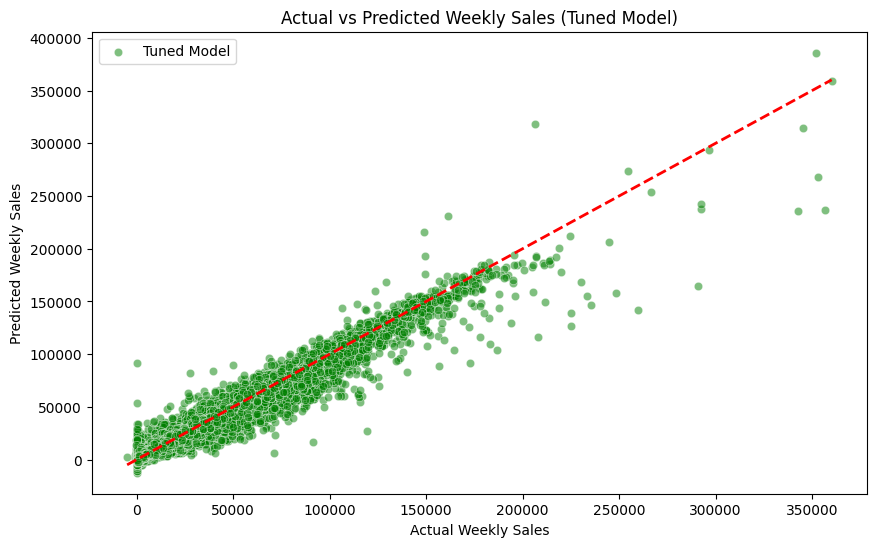

In [55]:
# 1. Generate predictions for the test data using the best model from GridSearchCV
y_test_pred_tuned = best_model.predict(X_test)

# 2. Calculate Mean Absolute Error (MAE)
mae_tuned = mean_absolute_error(y_test, y_test_pred_tuned)

# 3. Calculate R-squared score
r2_tuned = r2_score(y_test, y_test_pred_tuned)

# 4. Print the results
print(f'--- Tuned Model Performance ---')
print(f'Mean Absolute Error (MAE): {mae_tuned:.2f}')
print(f'R-squared Score: {r2_tuned:.4f}')

# 5. Compare with baseline performance
mae_baseline = 4267.41
r2_baseline = 0.8970

print('\n--- Comparison with Baseline ---')
print(f'MAE Improvement: {mae_baseline - mae_tuned:.2f}')
print(f'R2 Improvement: {r2_tuned - r2_baseline:.4f}')

# 6. Scatter plot of Actual vs. Predicted values for the tuned model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred_tuned, alpha=0.5, color='green', label='Tuned Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales (Tuned Model)')
plt.legend()
plt.show()

## Summary:

### Q&A
**What were the best hyperparameters found for the XGBoost model?**
The optimal configuration identified via `GridSearchCV` was:
*   `learning_rate`: 0.1
*   `max_depth`: 8
*   `n_estimators`: 200

**How did the tuned model perform compared to the baseline?**
The tuned model significantly outperformed the baseline, reducing the Mean Absolute Error (MAE) by **1,834.11** and increasing the R-squared (R²) score by **0.0674**.

### Data Analysis Key Findings
*   **Significant Error Reduction**: The Mean Absolute Error (MAE) dropped from a baseline of 4,267.41 to **2,433.30**, representing a substantial increase in the precision of weekly sales forecasts.
*   **Enhanced Variance Explanation**: The R-squared score improved from 0.8970 to **0.9644**, meaning the optimized model now accounts for approximately 96.44% of the variance in the sales data.
*   **Model Complexity**: The best parameters favored the maximum tested values for depth (8) and estimators (200), suggesting that the model benefited from higher complexity to capture the underlying patterns in the Walmart dataset.
*   **Predictive Reliability**: Visual analysis through scatter plots confirmed that the tuned model's predictions align much more closely with actual sales values across the entire distribution compared to previous iterations.
